In [1]:
import pandas as pd 
data=pd.read_csv(r"C:\Users\HEMANATH\Desktop\customer-churn-prediction\data\processed\featured_data.csv")
data.drop("Unnamed: 0",axis=1,inplace=True)
data

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,TenureGroup,SpendCategory,AvgSpendPerMonth,HighRiskCustomer,ServiceCount,StreamingCount,IsElectronicCheck,IsAutoPay,TotalEngagement,Contract_Tenure_Risk
0,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,...,New,Medium,1.971741,False,2,0,0,0,2,1
1,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,...,New,High,2.115063,False,0,0,1,0,0,1
2,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,New,High,8.152012,False,1,2,1,0,3,1
3,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Long,VeryHigh,28.790643,False,2,2,1,0,4,0
4,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Very Long,VeryHigh,48.102197,False,2,2,0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,...,Very Long,Low,64.081264,False,0,0,0,1,1,0
7028,34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,...,Mid,High,23.199301,False,3,2,0,0,5,0
7029,34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,...,Very Long,VeryHigh,70.661228,False,2,2,0,1,5,0
7030,34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,...,New,Low,11.321895,False,1,0,1,0,1,1


In [2]:
data.isna().sum()

Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Value             0
TenureGroup             0
SpendCategory           0
AvgSpendPerMonth        0
HighRiskCustomer        0
ServiceCount            0
StreamingCount          0
IsElectronicCheck       0
IsAutoPay               0
TotalEngagement         0
Contract_Tenure_Risk    0
dtype: int64

In [3]:
X=data.drop("Churn Value",axis=1)
y=data["Churn Value"]
X

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,TenureGroup,SpendCategory,AvgSpendPerMonth,HighRiskCustomer,ServiceCount,StreamingCount,IsElectronicCheck,IsAutoPay,TotalEngagement,Contract_Tenure_Risk
0,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,...,New,Medium,1.971741,False,2,0,0,0,2,1
1,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,...,New,High,2.115063,False,0,0,1,0,0,1
2,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,New,High,8.152012,False,1,2,1,0,3,1
3,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Long,VeryHigh,28.790643,False,2,2,1,0,4,0
4,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Very Long,VeryHigh,48.102197,False,2,2,0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,...,Very Long,Low,64.081264,False,0,0,0,1,1,0
7028,34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,...,Mid,High,23.199301,False,3,2,0,0,5,0
7029,34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,...,Very Long,VeryHigh,70.661228,False,2,2,0,1,5,0
7030,34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,...,New,Low,11.321895,False,1,0,1,0,1,1


In [4]:
y

0       1
1       1
2       1
3       1
4       1
       ..
7027    0
7028    0
7029    0
7030    0
7031    0
Name: Churn Value, Length: 7032, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,stratify=y)

In [6]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [8]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_prep,
    y_train
)

In [10]:
from collections import Counter

print(Counter(y_train))
print(Counter(y_train_smote))

Counter({0: 4130, 1: 1495})
Counter({0: 4130, 1: 4130})


In [11]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train_smote,y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=150,random_state=42)
rf.fit(X_train_smote,y_train_smote)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_smote,y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    # Probability scores for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }
    
    return metrics

In [15]:
results=[]

models={
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name,model in models.items():
    metrics=evaluate_model(model,X_test_prep,y_test)

    results.append({
        "Model":name,
        **metrics
    })


In [16]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.767591,0.542495,0.802139,0.647249,0.864762
1,Random Forest,0.793177,0.632588,0.529412,0.576419,0.854775
2,XGBoost,0.808102,0.657576,0.580214,0.616477,0.852175


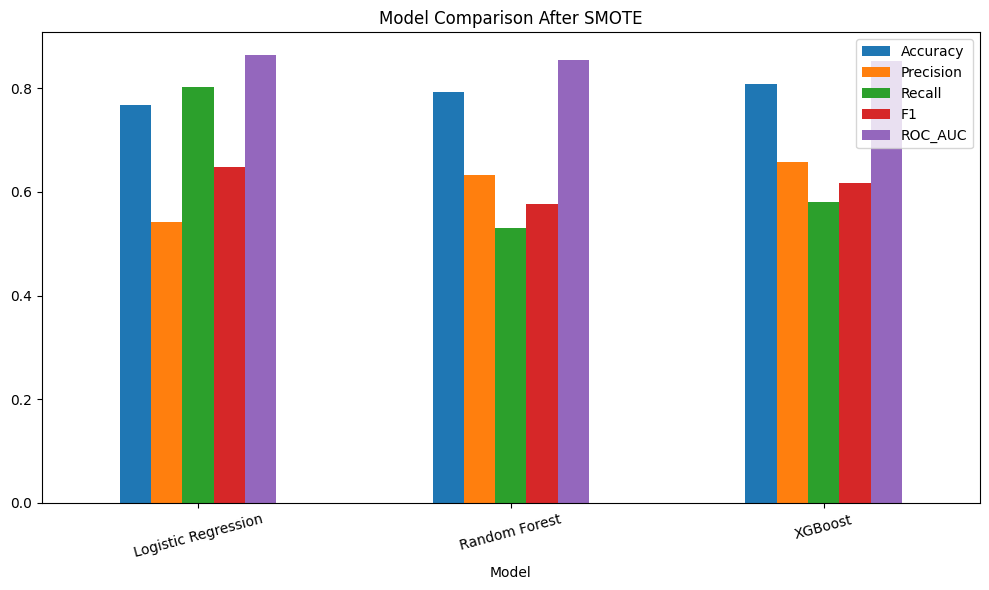

In [17]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison After SMOTE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
46,cat__Contract_Month-to-month,0.233377
26,cat__Internet Service_Fiber optic,0.086570
13,cat__Gender_Male,0.063171
18,cat__Dependents_No,0.057964
50,cat__Paperless Billing_Yes,0.053174
28,cat__Online Security_No,0.049656
37,cat__Tech Support_No,0.033617
58,cat__TenureGroup_Very Long,0.025152
30,cat__Online Security_Yes,0.022093
39,cat__Tech Support_Yes,0.019877


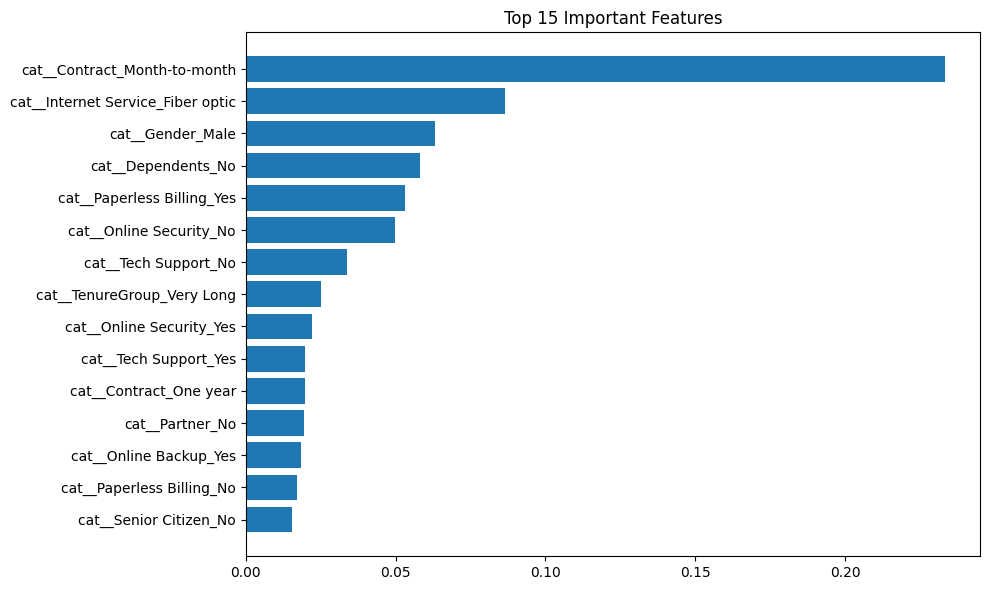

In [19]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

In [22]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

In [23]:
lr = LogisticRegression(max_iter=2000)

random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [24]:
random_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegre...max_iter=2000)
,param_distributions,"{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
print(random_search.best_params_)

{'solver': 'liblinear', 'penalty': 'l1', 'class_weight': None, 'C': 1}


In [26]:
print(random_search.best_score_)

0.8669415309933223


In [27]:
best_lr = random_search.best_estimator_

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = best_lr.predict(X_test_prep)

y_prob = best_lr.predict_proba(X_test_prep)[:,1]

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

Accuracy : 0.7668798862828714
Precision: 0.5415162454873647
Recall   : 0.8021390374331551
F1 Score : 0.646551724137931
ROC AUC  : 0.8647286600990832


In [29]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1","ROC_AUC"],
    "Before": [
        0.7697,
        0.5462,
        0.7887,
        0.6455,
        0.8612
    ],
    "After": [
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ]
})

comparison

,Metric,Before,After
0,Accuracy,0.7697,0.766880
1,Precision,0.5462,0.541516
2,Recall,0.7887,0.802139
3,F1,0.6455,0.646552
4,ROC_AUC,0.8612,0.864729


In [34]:
import joblib

joblib.dump(best_lr, r"C:\Users\HEMANATH\Desktop\customer-churn-prediction\models\logistic_model.pkl")
joblib.dump(preprocessor, r"C:\Users\HEMANATH\Desktop\customer-churn-prediction\models\preprocessor.pkl")

['C:\\Users\\HEMANATH\\Desktop\\customer-churn-prediction\\models\\preprocessor.pkl']

In [35]:
print(X.columns.tolist())

['Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'TenureGroup', 'SpendCategory', 'AvgSpendPerMonth', 'HighRiskCustomer', 'ServiceCount', 'StreamingCount', 'IsElectronicCheck', 'IsAutoPay', 'TotalEngagement', 'Contract_Tenure_Risk']


In [36]:
print(type(preprocessor))


<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [37]:
print(preprocessor.get_feature_names_out()[:10])

['num__Latitude' 'num__Longitude' 'num__Tenure Months'
 'num__Monthly Charges' 'num__Total Charges' 'num__AvgSpendPerMonth'
 'num__ServiceCount' 'num__StreamingCount' 'num__IsElectronicCheck'
 'num__IsAutoPay']
